In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================
# DOWNLOAD DATASET FROM KAGGLE
# =====================================================

import kagglehub

path = kagglehub.dataset_download(
    "fedesoriano/body-fat-prediction-dataset"
)

print("Dataset path:", path)

csv_path = os.path.join(path, "bodyfat.csv")

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

df = df[df['BodyFat'] > 0]
print('JSON export created for HTML integration.')

100%|██████████| 7.43k/7.43k [00:00<00:00, 12.1MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/fedesoriano/body-fat-prediction-dataset/versions/1
   Density  BodyFat  Age  Weight  Height  Neck  Chest  Abdomen    Hip  Thigh  \
0   1.0708     12.3   23  154.25   67.75  36.2   93.1     85.2   94.5   59.0   
1   1.0853      6.1   22  173.25   72.25  38.5   93.6     83.0   98.7   58.7   
2   1.0414     25.3   22  154.00   66.25  34.0   95.8     87.9   99.2   59.6   
3   1.0751     10.4   26  184.75   72.25  37.4  101.8     86.4  101.2   60.1   
4   1.0340     28.7   24  184.25   71.25  34.4   97.3    100.0  101.9   63.2   

   Knee  Ankle  Biceps  Forearm  Wrist  
0  37.3   21.9    32.0     27.4   17.1  
1  37.3   23.4    30.5     28.9   18.2  
2  38.9   24.0    28.8     25.2   16.6  
3  37.3   22.8    32.4     29.4   18.2  
4  42.2   24.0    32.2     27.7   17.7  
Index(['Density', 'BodyFat', 'Age', 'Weight', 'Height', 'Neck', 'Chest',
       'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm',
       'Wri

In [4]:
height_m = df['Height'] * 0.0254
weight_kg = df['Weight'] * 0.453592

df['BMI'] = weight_kg / (height_m ** 2)

In [5]:
abdomen = df['Abdomen']
hip = df['Hip']
thigh = df['Thigh']
bodyfat = df['BodyFat']

abdomen_n = abdomen / abdomen.max()
hip_n = hip / hip.max()
thigh_n = thigh / thigh.max()
bodyfat_n = bodyfat / bodyfat.max()

In [6]:
df['VisceralFatScore'] = (
    0.55 * abdomen_n +
    0.25 * bodyfat_n +
    0.20 * (df['Age'] / df['Age'].max())
)

# Subcutaneous

df['SubcutaneousFatScore'] = (
    0.45 * bodyfat_n +
    0.30 * hip_n +
    0.25 * thigh_n
)

# Gluteofemoral

df['GluteofemoralScore'] = (
    0.50 * hip_n +
    0.50 * thigh_n
)

In [7]:
np.random.seed(42)

df['PPARG'] = np.random.normal(0.6, 0.15, len(df))
df['FTO'] = np.random.normal(0.5, 0.2, len(df))
df['LEPR'] = np.random.normal(0.4, 0.1, len(df))


df['GeneticStorageIndex'] = (
    0.45 * df['PPARG'] +
    0.35 * df['FTO'] +
    0.20 * df['LEPR']
)


In [8]:
df['MetabolicRisk'] = (
    0.70 * df['VisceralFatScore'] +
    0.20 * df['BMI'] / df['BMI'].max() +
    0.10 * df['GeneticStorageIndex']
)


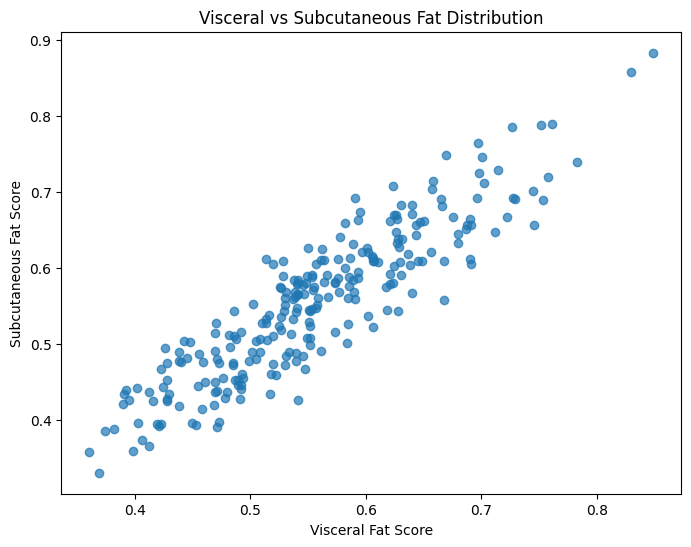

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['VisceralFatScore'],
    df['SubcutaneousFatScore'],
    alpha=0.7
)

plt.xlabel('Visceral Fat Score')
plt.ylabel('Subcutaneous Fat Score')
plt.title('Visceral vs Subcutaneous Fat Distribution')

plt.show()

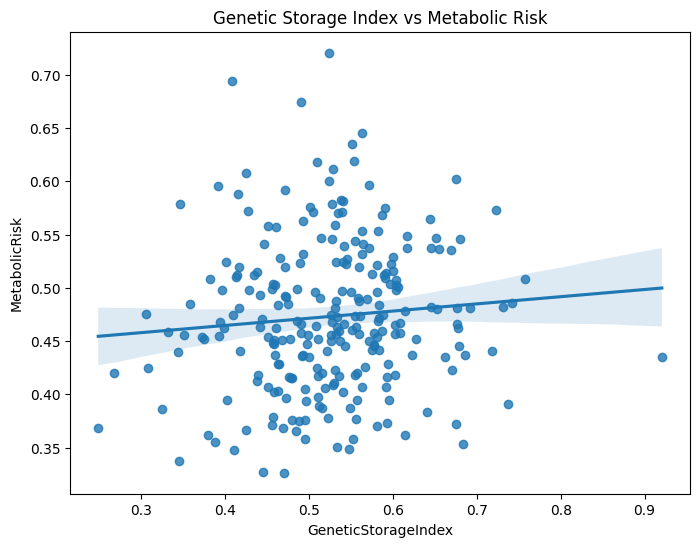

In [11]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=df['GeneticStorageIndex'],
    y=df['MetabolicRisk']
)

plt.title('Genetic Storage Index vs Metabolic Risk')

plt.show()

In [13]:
fig = px.scatter_3d(
    df,
    x='VisceralFatScore',
    y='SubcutaneousFatScore',
    z='GluteofemoralScore',
    color='MetabolicRisk',
    title='3D Fat Compartment Visualization'
)
fig.show()


In [14]:
features = df[[
    'VisceralFatScore',
    'SubcutaneousFatScore',
    'GluteofemoralScore'
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)


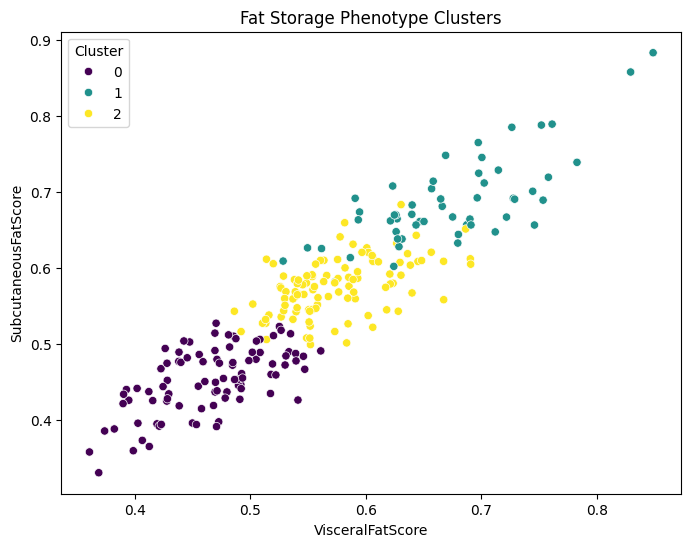

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['VisceralFatScore'],
    y=df['SubcutaneousFatScore'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title('Fat Storage Phenotype Clusters')

plt.show()

In [16]:
X = df[[
    'BMI',
    'Age',
    'PPARG',
    'FTO',
    'LEPR'
]]

Y = df['MetabolicRisk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
    )

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.029301967430180296
R2 Score: 0.8140773136778106


In [19]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

  Feature  Importance
0     BMI    0.696921
1     Age    0.210953
3     FTO    0.032507
2   PPARG    0.031137
4    LEPR    0.028483


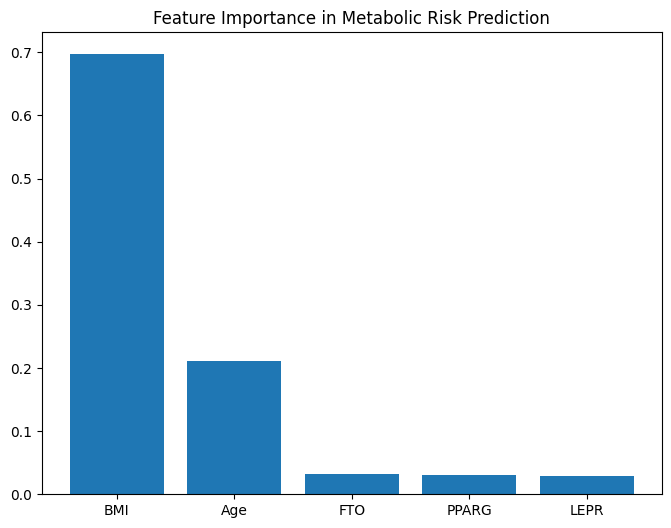

In [20]:
plt.figure(figsize=(8,6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance in Metabolic Risk Prediction')

plt.show()

In [21]:
output_path = '/content/genetic_fat_distribution_results.csv'

df.to_csv(output_path, index=False)

print('Saved:', output_path)

Saved: /content/genetic_fat_distribution_results.csv


In [22]:
mean_visceral = df['VisceralFatScore'].mean()
std_visceral = df['VisceralFatScore'].std()

print(
    f'Visceral Fat Score: {mean_visceral:.3f} ± {std_visceral:.3f}'
)

mean_risk = df['MetabolicRisk'].mean()
std_risk = df['MetabolicRisk'].std()

print(
    f'Metabolic Risk: {mean_risk:.3f} ± {std_risk:.3f}'
)

Visceral Fat Score: 0.556 ± 0.093
Metabolic Risk: 0.473 ± 0.070


In [23]:
html_export = df[[
    'BMI',
    'VisceralFatScore',
    'SubcutaneousFatScore',
    'GluteofemoralScore',
    'MetabolicRisk'
]]

html_export.to_json(
    '/content/fat_distribution_data.json',
    orient='records'
)

print('JSON export created for HTML integration.')

JSON export created for HTML integration.
